# **Detecção de Anomalias em Séries Temporais com Statistical Learning**

Séries de temporais reais nunca são perfeitamente desenhadas. Em geral, muitos pontos de dadosse desviam do padrão esperado, para cima ou para baixo, o que convencionalmente chamamos _outliers_ e identificá-los pode ajudar a identificar padrões e eventos importantes. Por exemplo: uma promoção que gerou um pico inesperado de consumo e ocasionou desabastecimento numa loja, um evento local que atraiu centenas de hóspedes extras para um hotel, ou posicionamento de preço frente ao mercado que impactou negativamente o volume de vendas. Em todo caso, identificar prováveis anomalias possibilita investigar melhor e compreender eventos próximos aos dias (ou hora, mês etc.) anômalos e antecipar futuros picos ou baixas. 

Este notebook tem como objetivo avaliar a progressão de métodos para detectar anomalias tomando como base os métodos explorados no paper [**_Automatic Anomaly Detection in the Cloud
Via Statistical Learning_** (Hochenbaum, Vallis & Kejariwal, 2017)](https://arxiv.org/abs/1704.07706), usando dados reais de vendas diárias a partir de 2021. Os autores exploram métodos tradicionais mais simples como a regra $3\sigma$  e avançam até o **_S-H-ESD_** — método proposto por pelos autores que combina decomposição STL com o teste estatístico _[extreme Studentized deviate (ESD)](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h3.htm)_.

## **Preparação do Notebook**

In [1]:
## o código abaixo instala a lib outliers se estiver usando uv
# !uv add outliers-utils
## ou use pip install diretamente
# !pip install outliers-utils

In [2]:
import warnings

warnings.filterwarnings("ignore")

import sys, os

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from outliers import smirnov_grubbs as esd
from scipy.stats import t as t_dist, median_abs_deviation

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 300,
    }
)

## **Como funciona a detecção?**

Toda série temporal possui três componentes sobrepostos: **tendência** (crescimento ou queda ao longo do tempo), **sazonalidade** (padrões recorrentes, como picos de consumo nos fins de semana) e **resíduo** (a parte não explicada pela tendência e sazonalidade).

Anomalias aparecem como valores extremos no **resíduo**. Como exemplo, em alguns contextos uma segunda-feira com alto volume de vendas é esperado, mas um volume extremamente alto traz indícios de anomalia, que é o que queremos analisar.

A abordagem proposta pelo artigo de referência usa a **decomposição STL** para isolar o resíduo e, em seguida, aplica o **teste ESD**. O teste aplica métodos estatísticos iterativamente para detectar múltiplos outliers de forma controlada, sem subestimar ou superestimar a taxa de resultados positivos.

## **Leitura dos Dados**

Os dados usados são uma série temporal real de vendas diárias a partir de janeiro de 2021 — período pós-pandemia, onde apresenta padrões de demanda mais estáveis. A sazonalidade dominante é semanal: picos em dias úteis, quedas nos fins de semana e feriados.

In [3]:
df = pd.read_csv("../data/daily_sales.csv")
df.head(5)

,unique_id,ds,y
0,SKU_02,2021-01-01,7.0
1,SKU_02,2021-01-02,2.0
2,SKU_02,2021-01-03,9.0
3,SKU_02,2021-01-04,98.0
4,SKU_02,2021-01-05,113.0


In [4]:
# funções auxiliares para visualização
def set_labels(ax):
    global fontdict
    fontdict = {"size": 14}

    ax.set_ylabel("y", fontdict=fontdict)
    ax.set_xlabel("ds", fontdict=fontdict)


def format_time_axis(ax, interval=3):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))
    plt.xticks(rotation=30, ha="right")


def set_caption(fig, caption):
    fig.text(x=0.035, y=-0.1, s=caption, ha="left", va="bottom", fontsize=15)


def set_legend(ax):
    ax.legend(loc="upper left", fontsize=10, framealpha=0.9)


def adjust_plot():
    plt.tight_layout()
    plt.show()

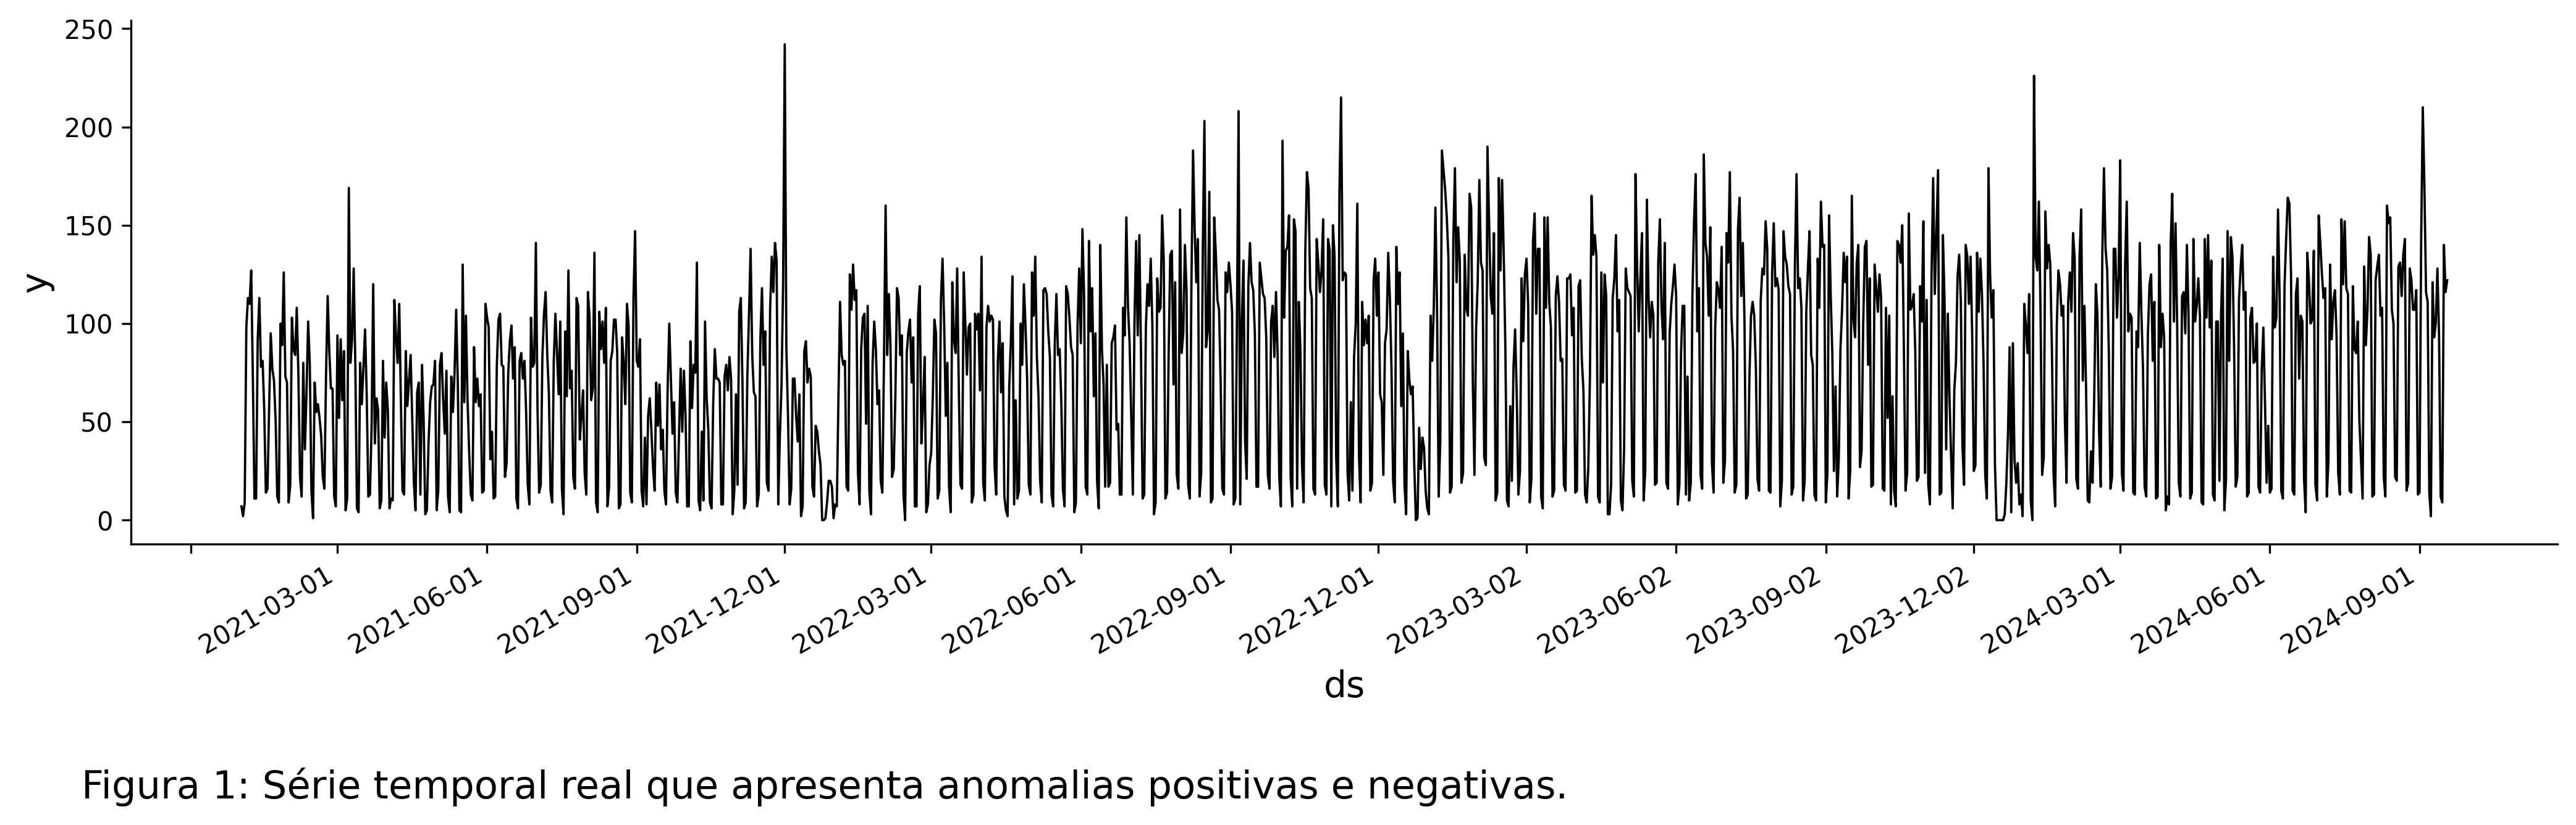

In [5]:
# fig 1: série temporal analisada
fig, ax = plt.subplots(figsize=(14, 4))
set_labels(ax=ax)

ax.plot(df["ds"], df["y"], color="black", linewidth=0.9)

caption = "Figura 1: Série temporal real que apresenta anomalias positivas e negativas. "
set_caption(fig, caption)
format_time_axis(ax)
adjust_plot()

## **Abordagem Clássica: Regra $3\sigma$**

Segundo o artigo, uma forma comum e direta de detectar anomalias em um determinado conjunto de dados é a **regra dos 3 desvios padrão**: qualquer valor além de $\mu$ ± $3\sigma$ é considerado anômalo. Apesar de ser um método amplamente utilizado em abordagens de análise descritiva e dados não temporais, apresenta um problema estrutural em séries sazonais e com tendência.

Como $\mu$ e $\sigma$ são calculados sobre a série inteira, mistura dias e períodos com diferentes padrões devido à variabilidade sazonal, que infla o desvio padrão. Em muitos casos, o intervalo $\mu$ ± $3\sigma$ fica extremamente largo, onde quase nenhum valor extremo é detectado.

In [6]:
# avaliação do método 3sigma
y = df["y"].to_numpy()
mu, sigma = y.mean(), y.std()
upper, lower = mu + 3 * sigma, mu - 3 * sigma
mask = (y > upper) | (y < lower)

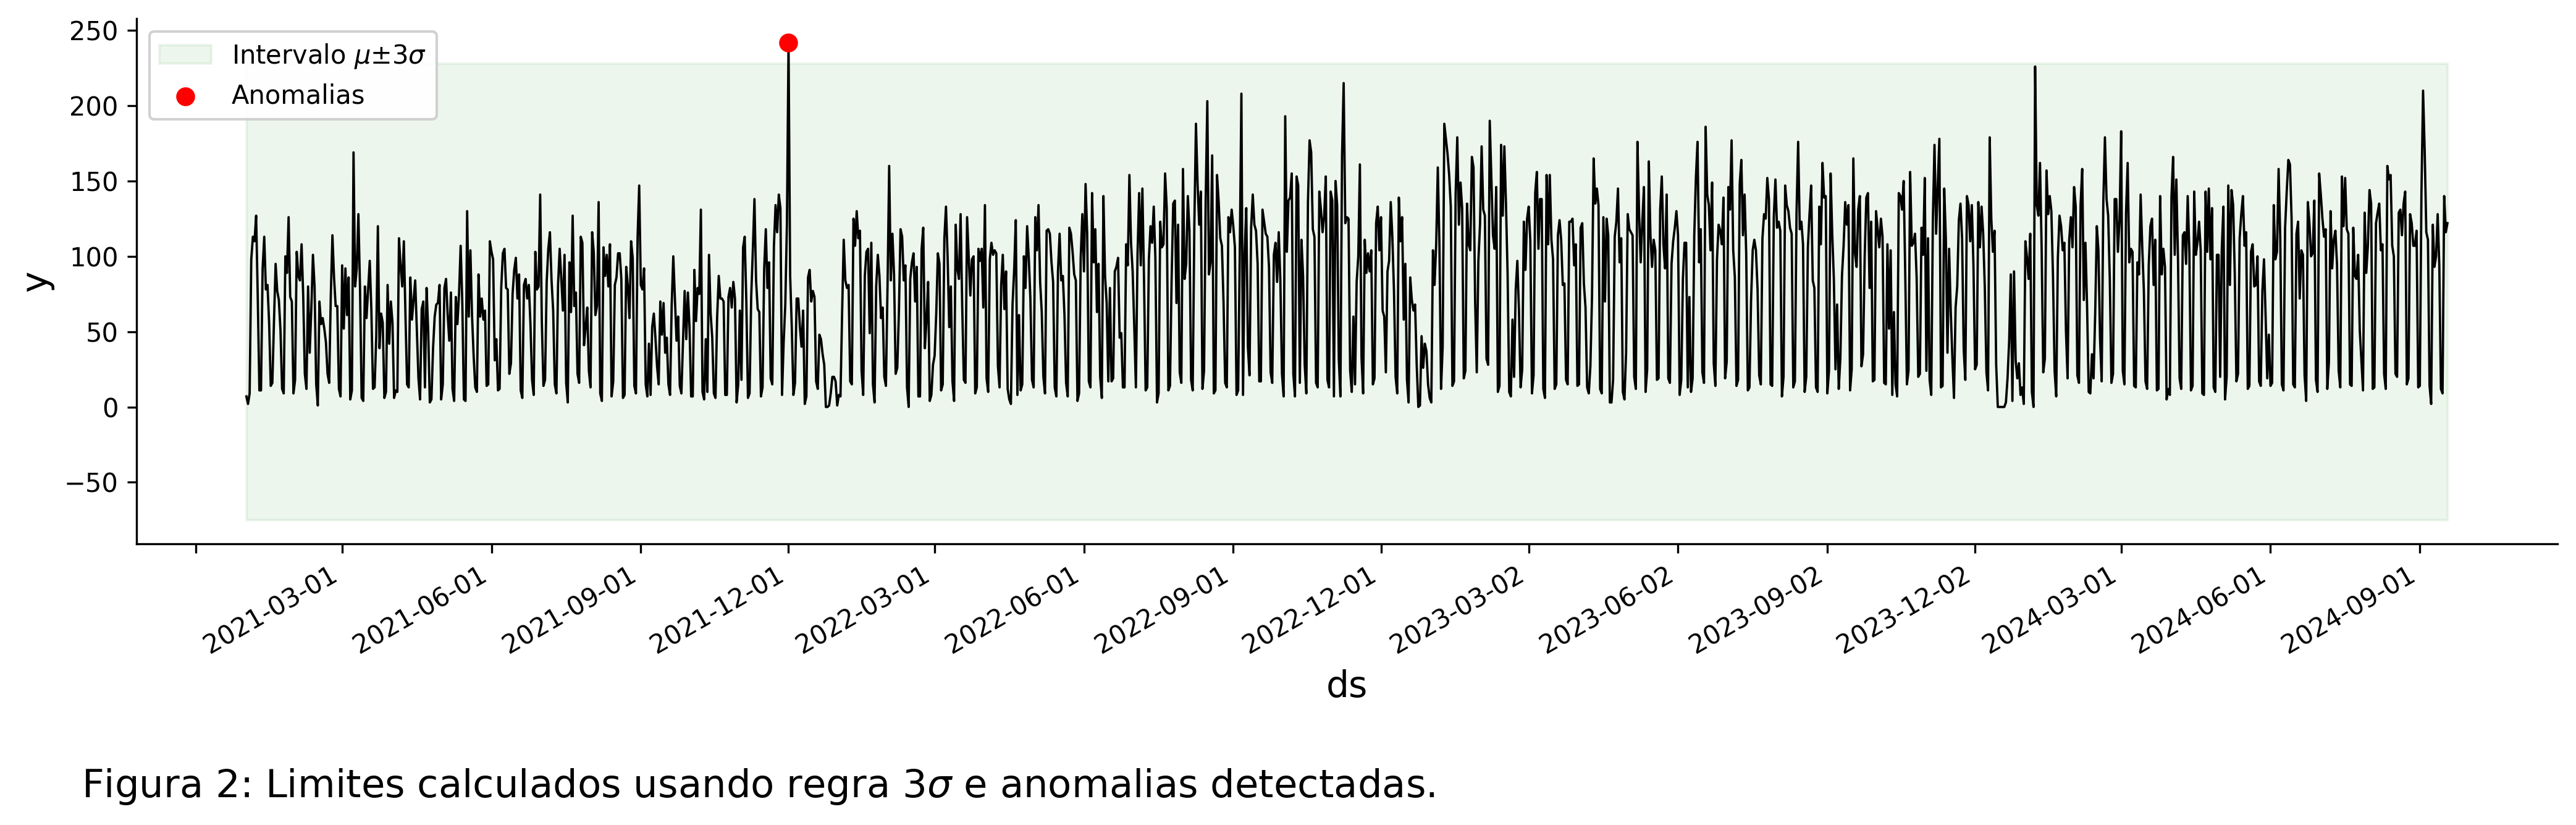

In [7]:
# fig 2: anomalias detectadas com 3sigma
fig, ax = plt.subplots(figsize=(14, 4))
set_labels(ax=ax)

ax.plot(df["ds"], y, color="black", linewidth=0.9)
ax.fill_between(
    df["ds"],
    lower,
    upper,
    alpha=0.07,
    color="green",
    label=f"Intervalo $\mu ± 3\sigma$",
)

ax.scatter(
    df["ds"][mask],
    y[mask],
    color="red",
    s=40,
    zorder=5,
    label=f"Anomalias",
)

caption = "Figura 2: Limites calculados usando regra $3\sigma$ e anomalias detectadas. "
set_caption(fig=fig, caption=caption)

set_legend(ax)
format_time_axis(ax)
adjust_plot()

## **Decomposição STL**

Para detectar as anomalias em uma série temporal adequadamente primeiro é necessário remover o que é o padrão esperado, ou seja: a tendência e a sazonalidade. O _**STL** (Seasonal-Trend decomposition using Loess)_ faz isso de forma robusta, ou seja: mesmo quando a série apresenta outliers.

Seguindo a proposta do artigo, o resíduo usado não é o padrão  **STL** ($R = y - \text{tendência} - \text{sazonalidade}$). A tendência foi substituida pea **mediana global** da série:

$$
R_t = y_t - \hat{S}_t - \tilde{y}
$$

Isso evita que eventos prolongados, como desabastecimentos entre outros, seja absorvido pela tendência e gere falsos positivos nos dias adjacentes.

In [8]:
# estimando decomposição STL
stl_model = STL(df.set_index("ds")["y"], period=7, robust=True).fit()

labels = ["y", "tendência", "sazonalidade", "resíduo"]
values = [
    df["y"].values,
    stl_model.trend.values,
    stl_model.seasonal.values,
    stl_model.resid.values,
]

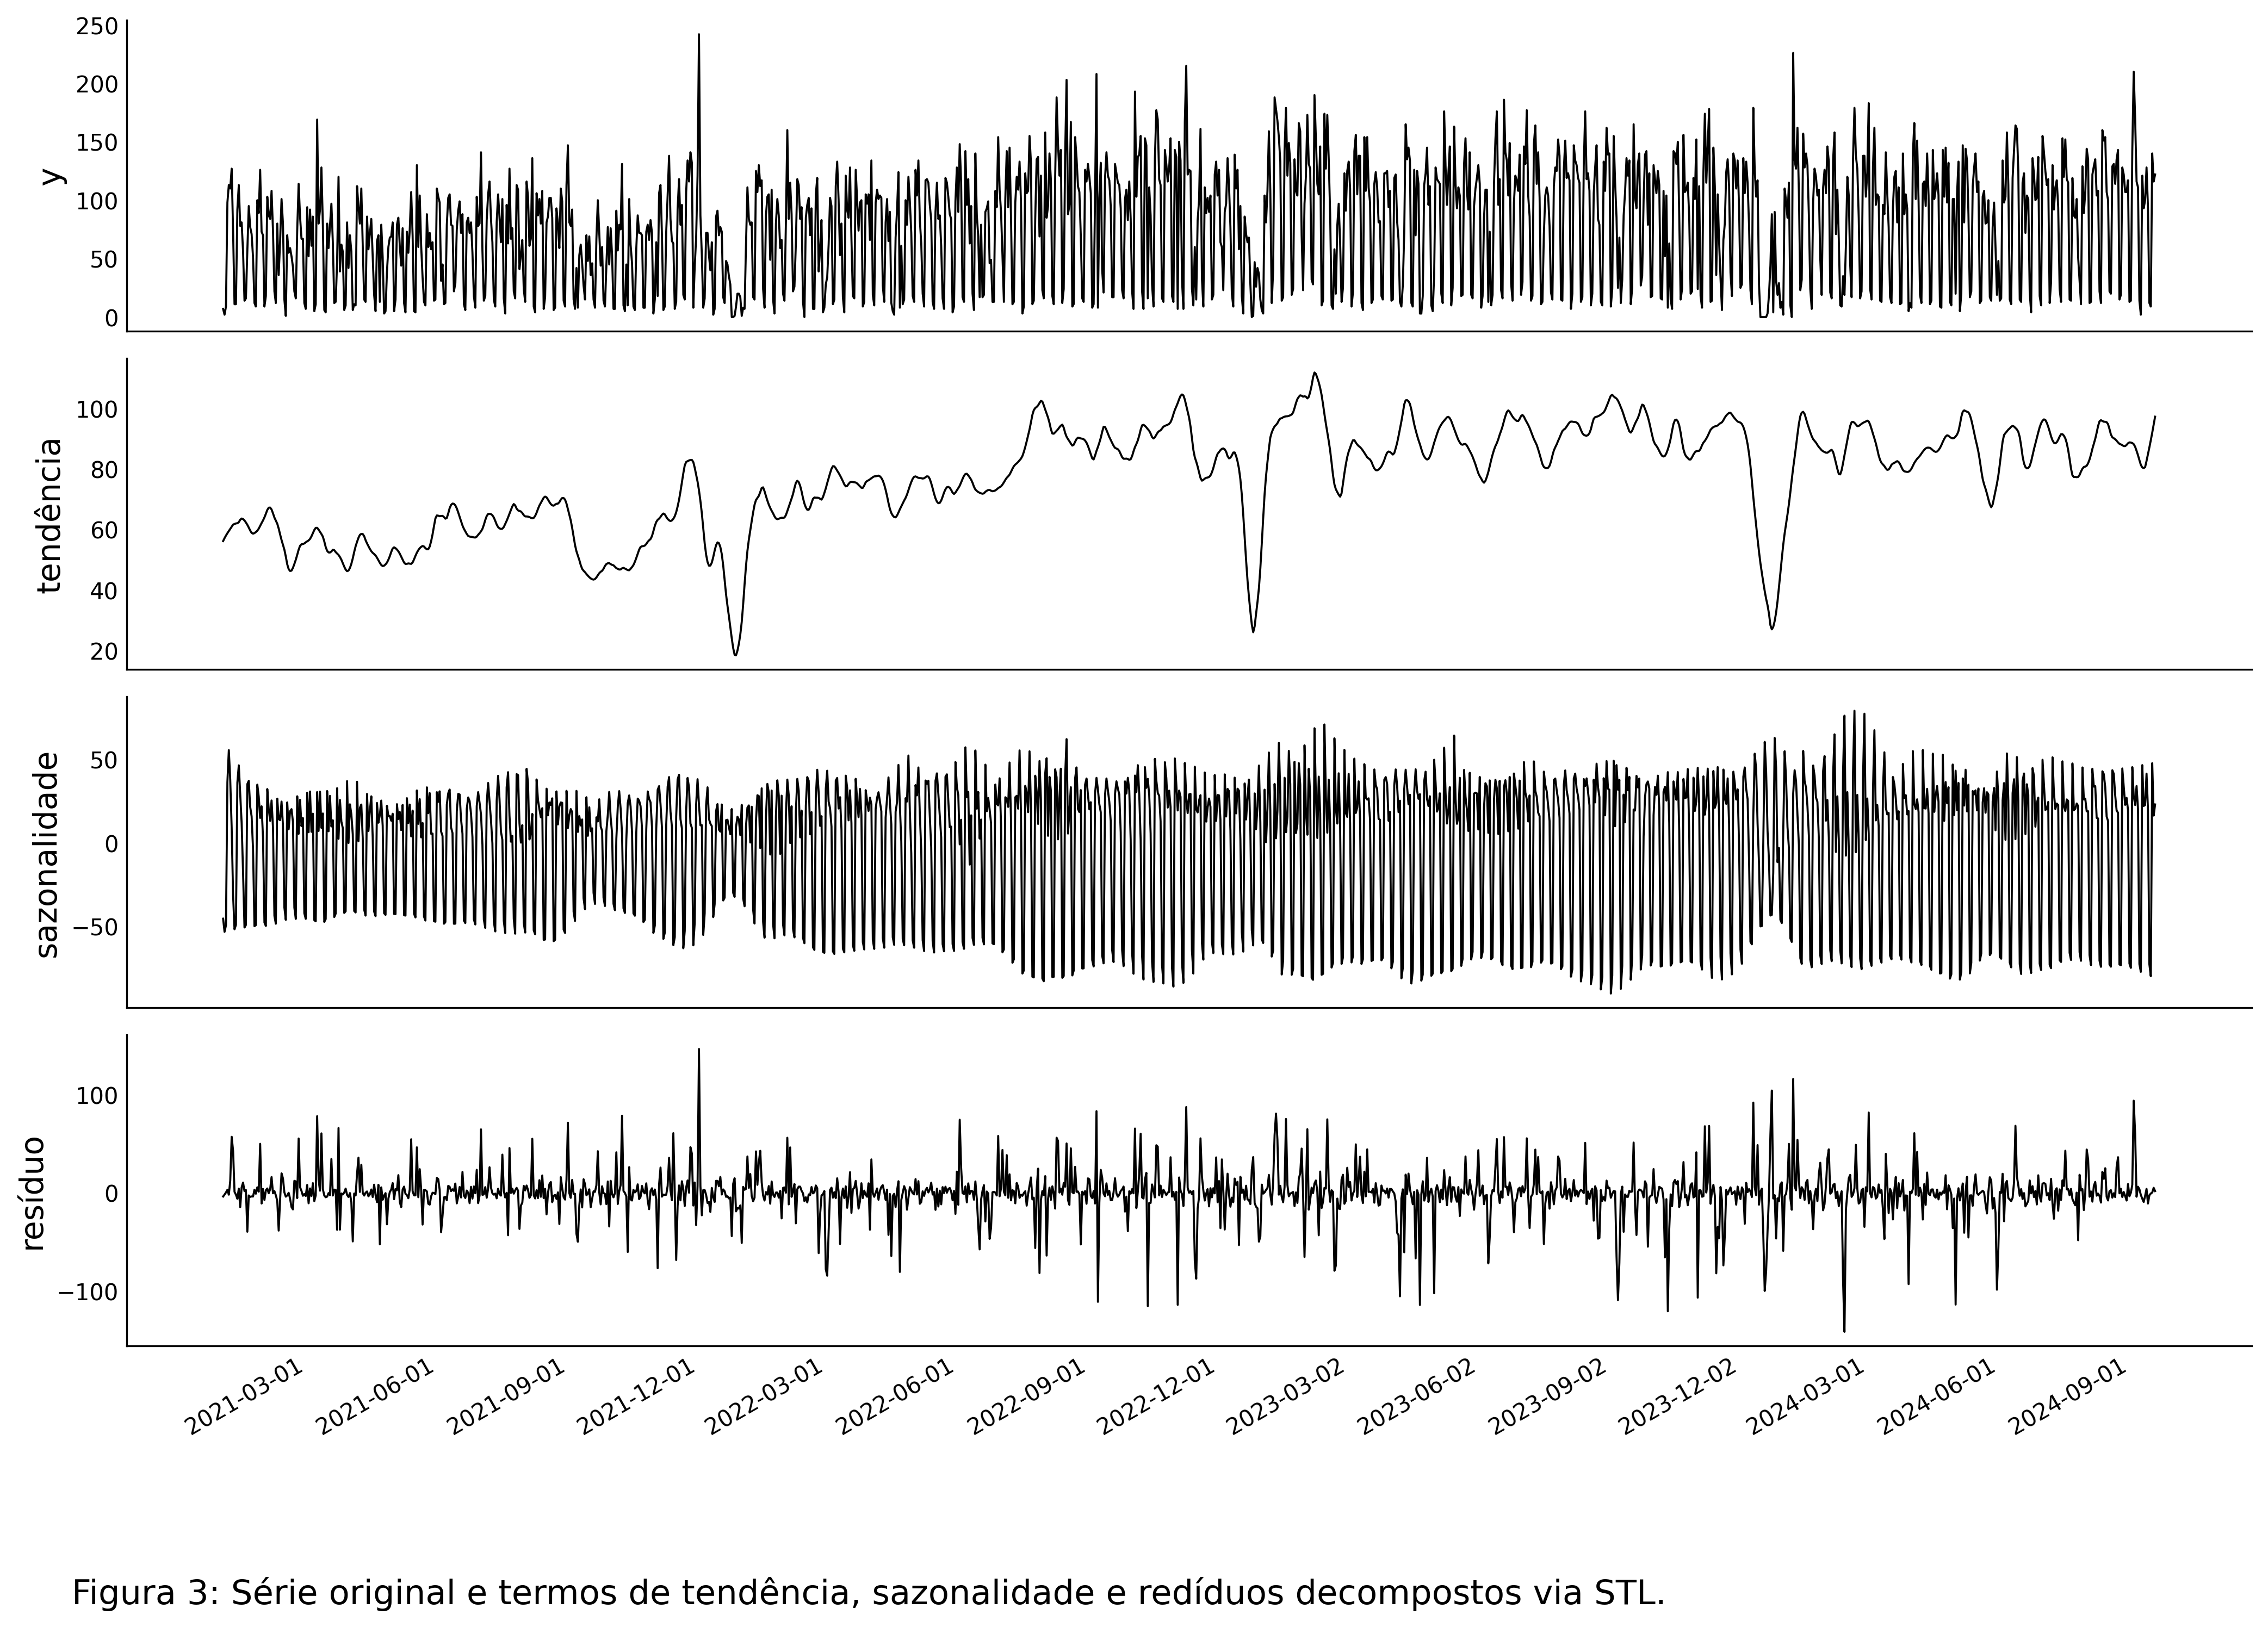

In [9]:
# fig 3: termos stl decompostos
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

for ax, label, vals in zip(axes, labels, values):
    ax.plot(df["ds"], vals, color="black", linewidth=0.9)
    ax.set_ylabel(label, fontdict=fontdict)
    ax.tick_params(axis="both", which="both", length=0)

format_time_axis(ax=ax)

plt.xticks(rotation=30, ha="right")

caption = "Figura 3: Série original e termos de tendência, sazonalidade e redíduos decompostos via STL."
set_caption(fig=fig, caption=caption)

plt.tight_layout()
plt.show()

## **S-ESD: Seasonal ESD**

Uma vez encontrados os resíduos $R_t$ pela variante STL, aplicamos o **S-ESD**: um teste estatístico que avalia iterativamente quais valores do resíduo são extremos o suficiente para serem considerados anomalias. A estatística de teste em cada iteração $i$ é:

$$G_i = \frac{\max_j \, |R_j - \bar{R}|}{s_R}$$

onde $\bar{R}$ é a média e $s_R$ o desvio padrão dos resíduos restantes. O candidato mais extremo é removido, o teste recalcula $G_i$ e compara com o valor crítico $\lambda_i$ — baseado na distribuição $t$ de Student. O número de outliers detectados é o maior $i$ tal que $G_i > \lambda_i$.

In [10]:
class SESDDetector:
    """
    Detector S-ESD com decomposição STL variante
    (Hochenbaum et al., 2017).
    """

    def __init__(
        self,
        time_col: str = "ds",
        target_col: str = "y",
        id_col: str = "unique_id",
        period: int = 7,
        robust: bool = True,
    ) -> None:
        self.time_col = time_col
        self.target_col = target_col
        self.id_col = id_col
        self.period = period
        self.robust = robust

    def compute_sesd_residual(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Variante STL do artigo.

        Computa o resíduo:
            R_t = yt - St(STL) - median(y)
        """
        series = df.set_index(self.time_col)[self.target_col]
        result = STL(series, period=self.period, robust=self.robust).fit()
        global_median = float(np.median(series.values))

        return df.assign(
            stl_seasonal=result.seasonal.values,
            stl_trend=result.trend.values,
            stl_resid=result.resid.values,
            stl_weights=result.weights.values,
            global_median=global_median,
            sesd_resid=series.values - result.seasonal.values - global_median,
        )

    def detect_outliers(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        S-ESD: aplica STL variante + teste ESD iterativo.
        """
        results = []

        for sku in df[self.id_col].unique():
            sub = df[df[self.id_col] == sku].copy().reset_index(drop=True)
            sub = self.compute_sesd_residual(sub)

            residuals = sub["sesd_resid"].to_numpy()
            max_idx = esd.max_test_indices(residuals)
            min_idx = esd.min_test_indices(residuals)

            sub["max_outlier"] = 0
            sub["min_outlier"] = 0
            sub.loc[max_idx, "max_outlier"] = 1
            sub.loc[min_idx, "min_outlier"] = 1
            sub["is_outlier"] = ((sub["max_outlier"] + sub["min_outlier"]) > 0).astype(
                int
            )

            results.append(sub)

        return pd.concat(results, ignore_index=True)

In [11]:
df_sesd = SESDDetector(period=7, robust=True).detect_outliers(df)
df_sesd.head()

,unique_id,ds,y,stl_seasonal,stl_trend,stl_resid,stl_weights,global_median,sesd_resid,max_outlier,min_outlier,is_outlier
0,SKU_02,2021-01-01,7.0,-45.400820,56.178754,-3.777934,0.976584,84.0,-31.599180,0,0,0
1,SKU_02,2021-01-02,2.0,-53.292045,57.136031,-1.843987,0.994414,84.0,-28.707955,0,0,0
2,SKU_02,2021-01-03,9.0,-49.338921,57.998350,0.340571,0.999815,84.0,-25.661079,0,0,0
3,SKU_02,2021-01-04,98.0,36.216071,58.777218,3.006711,0.985281,84.0,-22.216071,0,0,0
4,SKU_02,2021-01-05,113.0,55.432782,59.492742,-1.925523,0.993895,84.0,-26.432782,0,0,0


In [12]:
# pontos de anomalia detectados pelo S-ESD
max_pts = df_sesd[df_sesd["max_outlier"] == 1]
min_pts = df_sesd[df_sesd["min_outlier"] == 1]

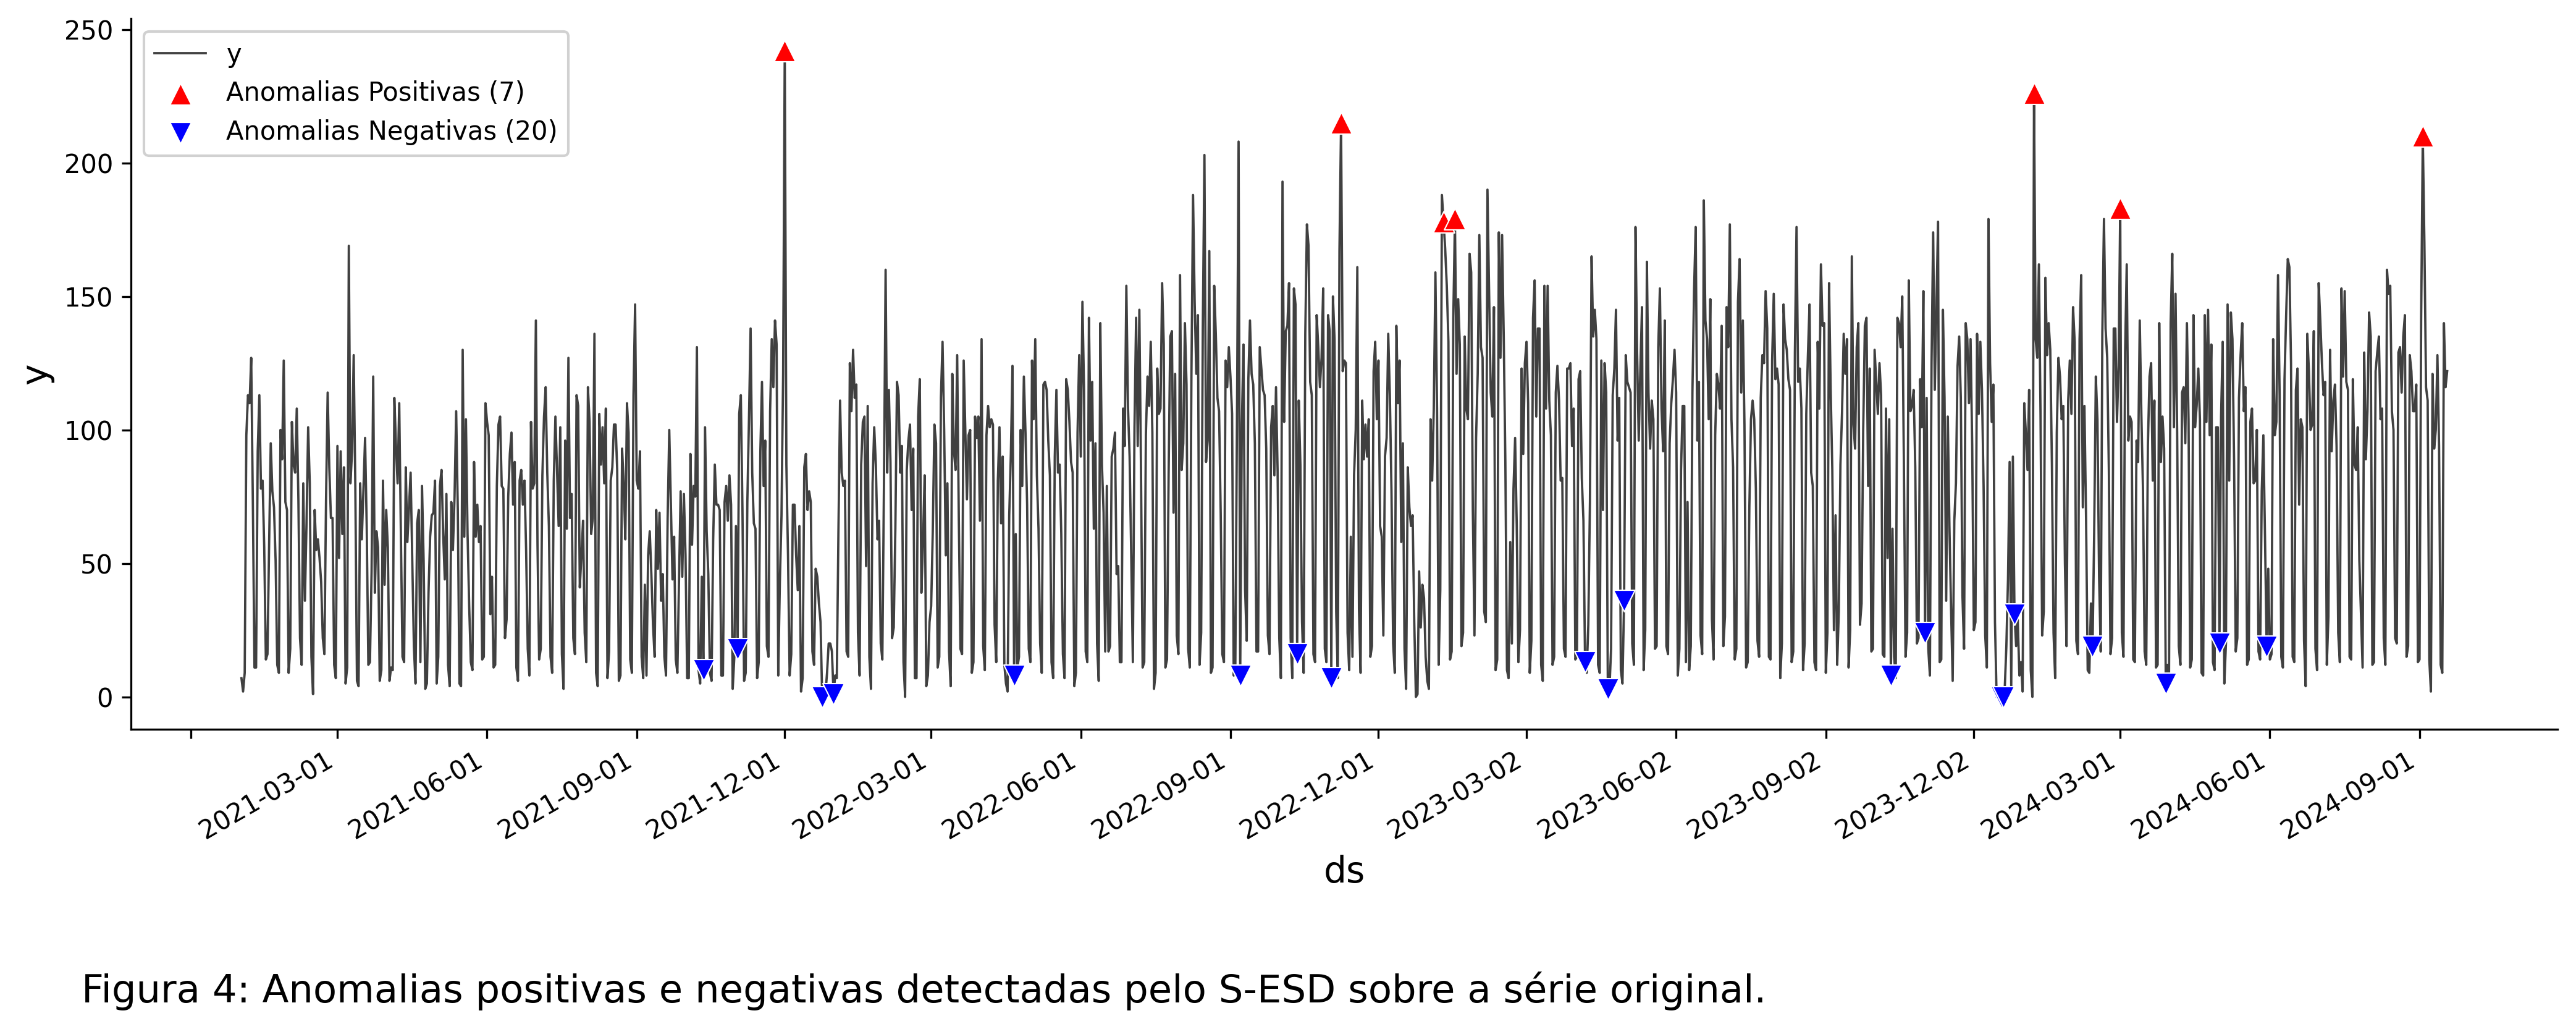

In [13]:
# fig 4: anomalias detectadas com S-ESD
c_high = "red"
c_low = "blue"

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_sesd["ds"],
    df_sesd["y"],
    color="black",
    linewidth=0.9,
    alpha=0.75,
    zorder=2,
    label="y",
)

ax.scatter(
    max_pts["ds"],
    max_pts["y"],
    color=c_high,
    s=70,
    zorder=5,
    marker="^",
    edgecolors="white",
    linewidths=0.5,
    label=f"Anomalias Positivas ({len(max_pts)})",
)

ax.scatter(
    min_pts["ds"],
    min_pts["y"],
    color=c_low,
    s=70,
    zorder=5,
    marker="v",
    edgecolors="white",
    linewidths=0.5,
    label=f"Anomalias Negativas ({len(min_pts)})",
)

caption = "Figura 4: Anomalias positivas e negativas detectadas pelo S-ESD sobre a série original."
set_caption(fig=fig, caption=caption)
set_legend(ax=ax)
set_labels(ax=ax)
format_time_axis(ax=ax)
adjust_plot()

## **S-H-ESD: Seasonal Hybrid ESD**

O **S-H-ESD** usa os mesmos resíduos $R_t$ obtidos pela variante STL, mas substitui a estatística central do teste: em vez de média e desvio padrão, utiliza mediana e [MAD (_Median Absolute Deviation_)](https://doi.org/10.1016/j.jesp.2013.03.013), que são estimadores resistentes à própria presença dos outliers que buscamos detectar.

A estatística de teste em cada iteração $i$ é:

$$G_i = \frac{\max_j \, |R_j - \tilde{R}|}{\text{MAD}(R)}, \qquad \text{MAD} = 1.4826 \cdot \text{mediana}\!\left(|R_j - \tilde{R}|\right)$$

onde o fator $1{,}4826$ torna o MAD assintoticamente equivalente ao desvio padrão em distribuições normais. O valor crítico $\lambda_i$ segue a mesma fórmula do S-ESD, baseada na distribuição $t$ de Student com $n - i - 1$ graus de liberdade.

Para distribuições com caudas longas, como os resíduos de séries de vendas, que apresentam muitos valores próximos de zero, o MAD tende a ser menor que o desvio padrão, logo, com o denominador menor, $G_i$ cresce, tornando o método mais sensível, o que em termos práticos possibilita capturar tanto anomalias extremas quanto desvios menores que o S-ESD não captura. 

Em termos práticos, o **S-ESD** é mais conservador pois detecta menos anomalias, o que implica em boa confiabilidade individual, enquanto o **S-H-ESD** é mais abrangente e cobre um conjunto maior de valores extremos, o que o torna útil para análises exploratórias e construção de calendários de eventos, por exemplo.

In [14]:
class SHESDDetector(SESDDetector):
    """
    Detector S-H-ESD com decomposição STL variante
    e estatística de teste robusta (mediana + MAD).
    (Hochenbaum et al., 2017 — Seção 3.5).
    """

    @staticmethod
    def _critical_value(n_orig: int, i: int, alpha: float = 0.05) -> float:
        """
        Valor crítico λ_i do teste ESD na iteração i (NIST / artigo Eq. 6).

            p      = 1 - alpha / (2 * (n - i + 1))
            df     = n - i - 1
            lambda = (n-i) * t_{p,df} / sqrt((n-i-1 + t²) * (n-i+1))
        """
        p = 1 - alpha / (2 * (n_orig - i + 1))
        df = n_orig - i - 1
        if df <= 0:
            return np.inf
        t_val = t_dist.ppf(p, df)
        return ((n_orig - i) * t_val) / np.sqrt(
            (n_orig - i - 1 + t_val**2) * (n_orig - i + 1)
        )

    def _shesd_indices(
        self,
        residuals: np.ndarray,
        max_outliers: int | None = None,
        alpha: float = 0.05,
    ) -> list[int]:
        """
        Teste S-H-ESD iterativo: detecta outliers usando mediana e MAD.
        Retorna os índices originais das anomalias detectadas.
        """
        n = len(residuals)
        if max_outliers is None:
            max_outliers = max(1, int(n * 0.1))
        max_outliers = min(max_outliers, int(n * 0.499))

        data = residuals.astype(float).copy()
        indices = np.arange(n)
        test_stats, crit_vals, removed_idxs = [], [], []

        for i in range(1, max_outliers + 1):
            if len(data) < 3:
                break
            med = np.median(data)
            mad = median_abs_deviation(data, scale=1.4826)
            if mad == 0:
                break
            deviations = np.abs(data - med)
            local_max = int(np.argmax(deviations))

            test_stats.append(deviations[local_max] / mad)
            crit_vals.append(self._critical_value(n, i, alpha))
            removed_idxs.append(int(indices[local_max]))

            data = np.delete(data, local_max)
            indices = np.delete(indices, local_max)

        num_outliers = 0
        for i, (g, lam) in enumerate(zip(test_stats, crit_vals)):
            if g > lam:
                num_outliers = i + 1

        return sorted(removed_idxs[:num_outliers])

    def detect_outliers(self, df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
        """
        S-H-ESD aplicado a múltiplas séries.
        """
        results = []

        for sku in df[self.id_col].unique():
            sub = df[df[self.id_col] == sku].copy().reset_index(drop=True)
            sub = self.compute_sesd_residual(sub)

            residuals = sub["sesd_resid"].to_numpy()
            outlier_idx = self._shesd_indices(residuals, alpha=alpha)

            sub["shesd_outlier"] = 0
            if outlier_idx:
                sub.loc[outlier_idx, "shesd_outlier"] = 1

            results.append(sub)

        return pd.concat(results, ignore_index=True)

In [15]:
# aplicando S-H-ESD à série
df_shesd = SHESDDetector(period=7, robust=True).detect_outliers(df)
df_shesd.head()

,unique_id,ds,y,stl_seasonal,stl_trend,stl_resid,stl_weights,global_median,sesd_resid,shesd_outlier
0,SKU_02,2021-01-01,7.0,-45.400820,56.178754,-3.777934,0.976584,84.0,-31.599180,0
1,SKU_02,2021-01-02,2.0,-53.292045,57.136031,-1.843987,0.994414,84.0,-28.707955,0
2,SKU_02,2021-01-03,9.0,-49.338921,57.998350,0.340571,0.999815,84.0,-25.661079,0
3,SKU_02,2021-01-04,98.0,36.216071,58.777218,3.006711,0.985281,84.0,-22.216071,0
4,SKU_02,2021-01-05,113.0,55.432782,59.492742,-1.925523,0.993895,84.0,-26.432782,0


In [16]:
# métricas de comparação S-ESD vs S-H-ESD
sesd_pts = df_sesd[df_sesd["is_outlier"] == 1]
shesd_pts = df_shesd[df_shesd["shesd_outlier"] == 1]
resid = df_sesd["sesd_resid"].to_numpy()

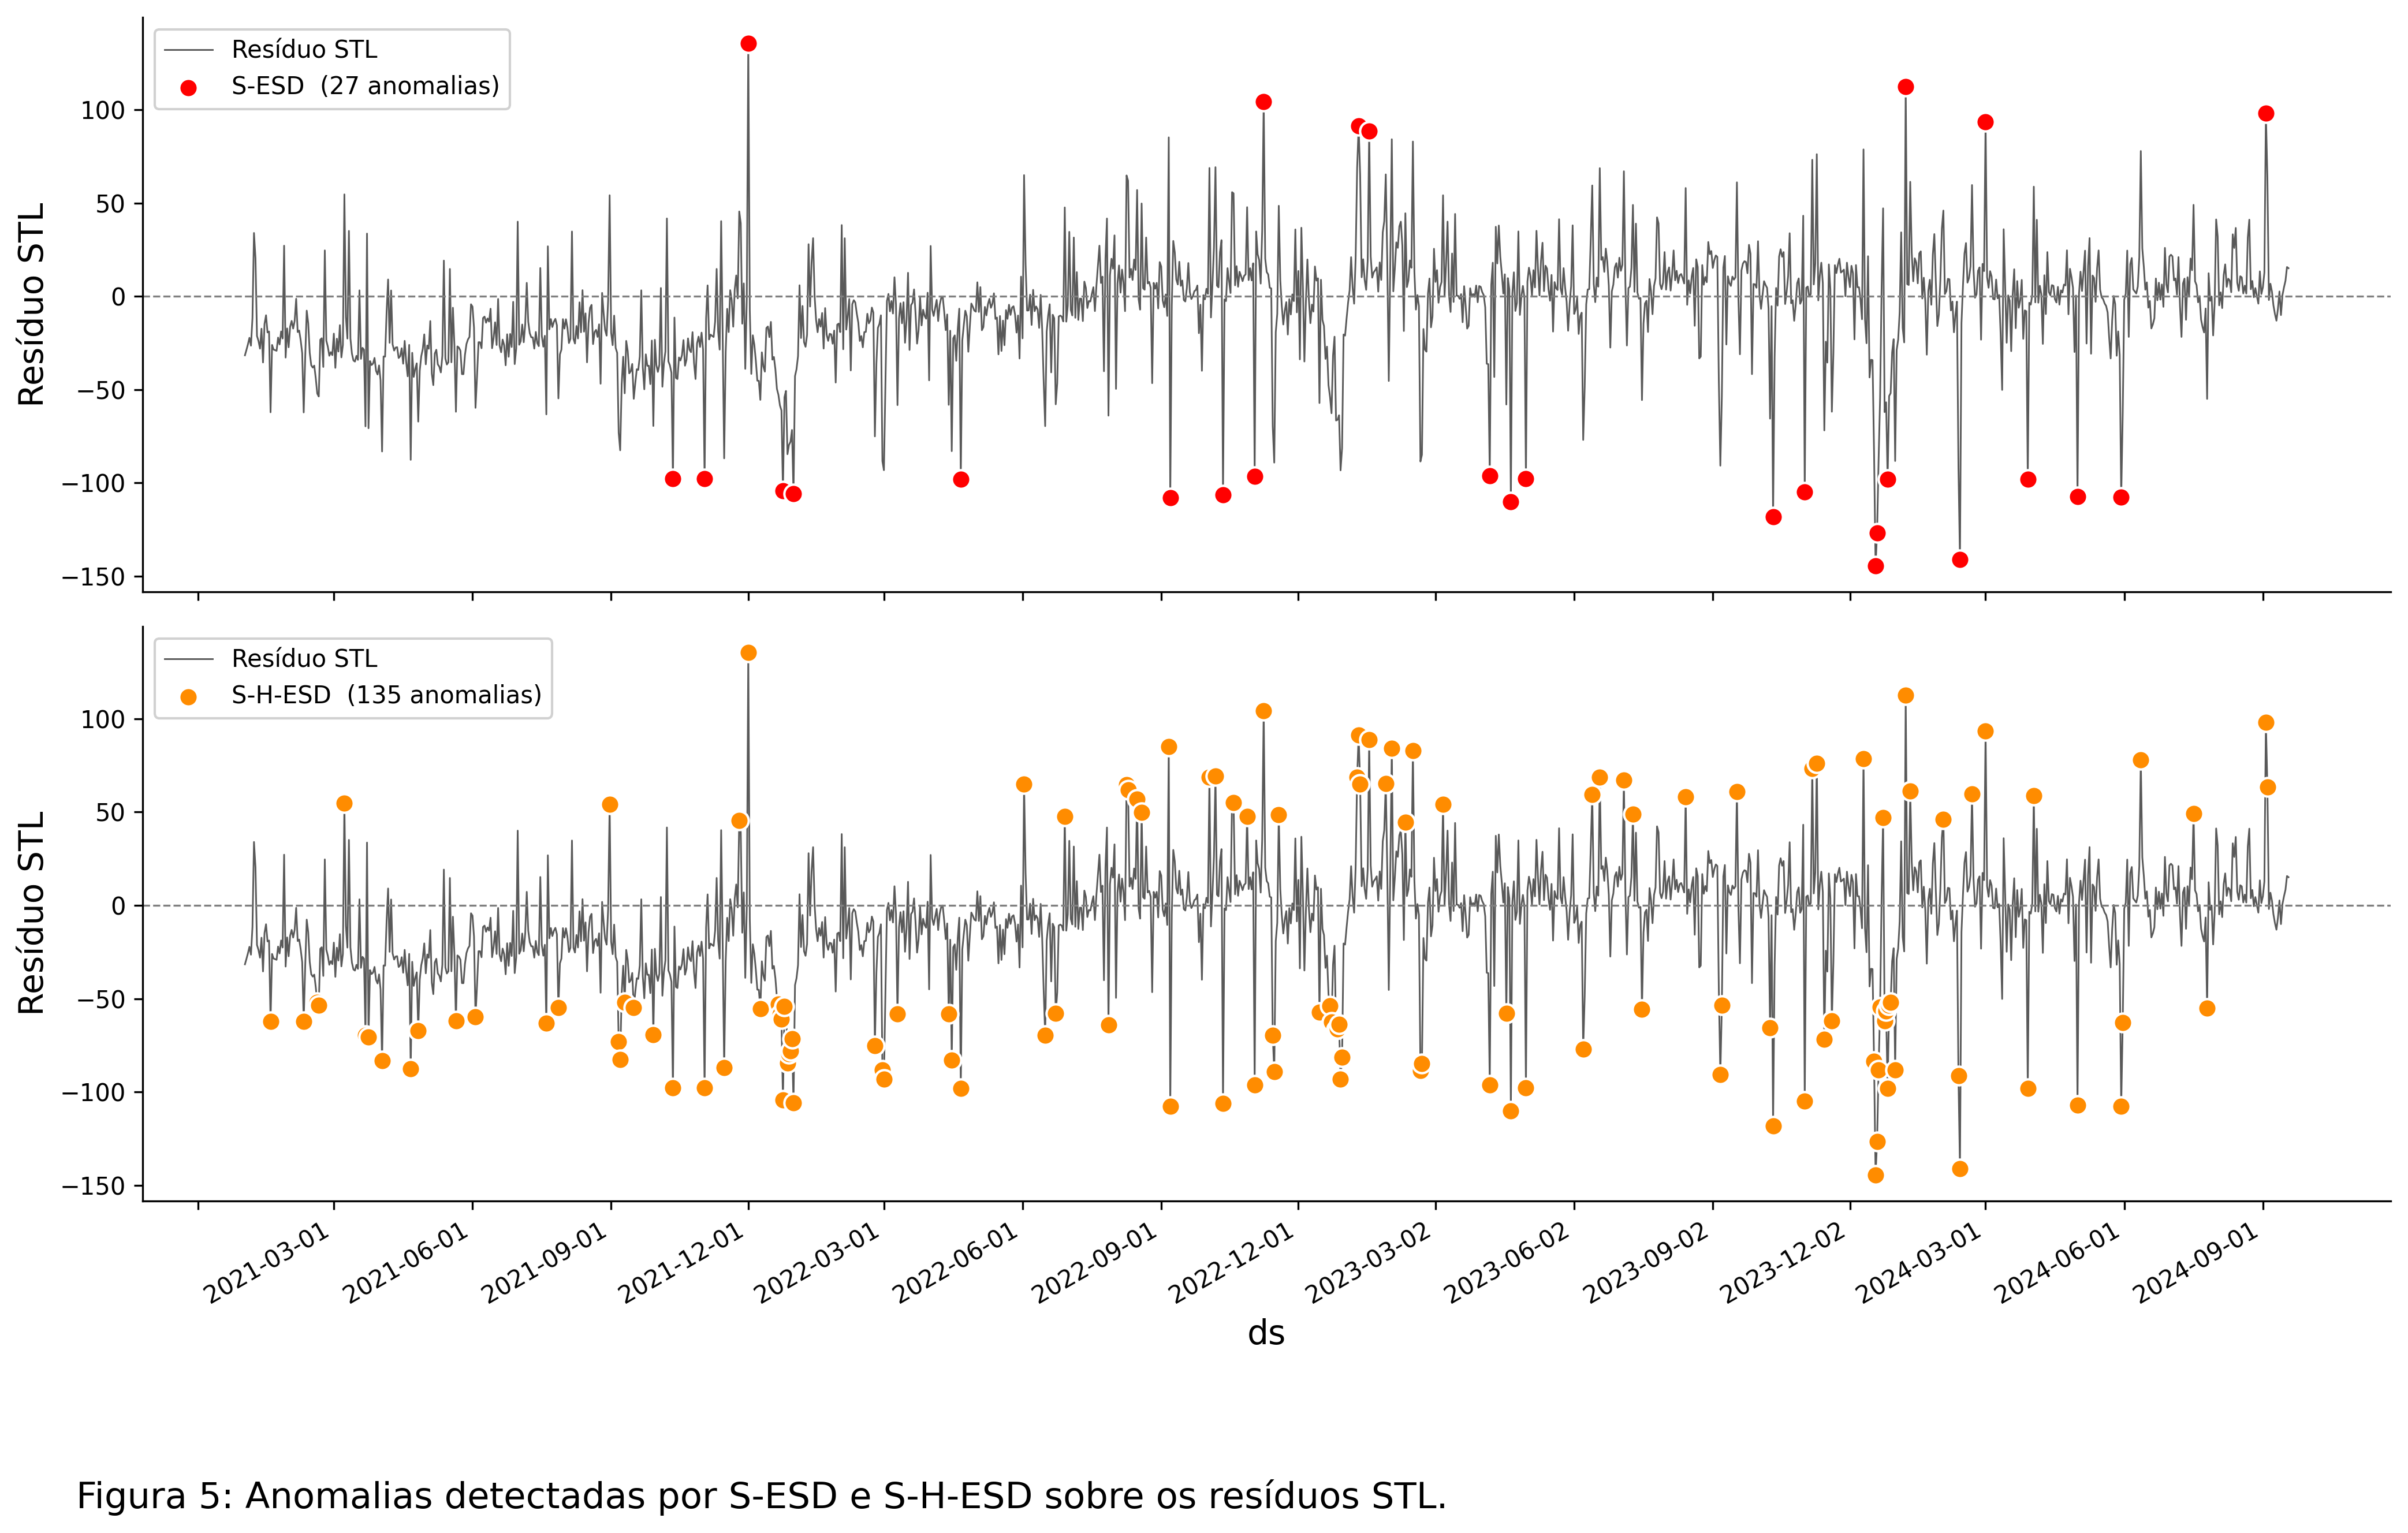

In [17]:
# fig 5: comparação S-ESD vs S-H-ESD nos resíduos STL
color = "black"
color_esd = "red"
color_shesd = "darkorange"

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, pts, title, c in zip(
    axes,
    [sesd_pts, shesd_pts],
    [f"S-ESD  ({len(sesd_pts)} anomalias)", f"S-H-ESD  ({len(shesd_pts)} anomalias)"],
    [color_esd, color_shesd],
):
    ax.plot(
        df_sesd["ds"], resid, color=color, linewidth=0.7, alpha=0.65, label="Resíduo STL"
    )
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.scatter(
        pts["ds"],
        pts["sesd_resid"],
        color=c,
        s=60,
        zorder=5,
        marker="o",
        edgecolors="white",
        label=title,
    )
    ax.set_ylabel("Resíduo STL", fontdict=fontdict)
    set_legend(ax=ax)
axes[-1].set_xlabel("ds", fontdict=fontdict)

caption = f"Figura 5: Anomalias detectadas por S-ESD e S-H-ESD sobre os resíduos STL. "
format_time_axis(ax=ax)
set_caption(fig=fig, caption=caption)
adjust_plot()

## **Referências**

1. [Hochenbaum, J., Vallis, O. S., & Kejariwal, A. (2017). *Automatic Anomaly Detection in the Cloud Via Statistical Learning*. arXiv:1704.07706.](https://arxiv.org/abs/1704.07706)
2. [Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). *STL: A Seasonal-Trend Decomposition Procedure Based on Loess*. Journal of Official Statistics, 6(1), 3–73.](https://www.math.unm.edu/~lil/Stat581/STL.pdf)
3.  [NIST/SEMATECH. *Generalized ESD Many-Outlier Procedure*. e-Handbook of Statistical Methods.](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h3.htm)
4. [Leys, C., Ley, C., Klein, O., Bernard, P., & Licata, L. (2013). *Detecting outliers: Do not use standard deviation around the mean, use absolute deviation around the median*. Journal of Experimental Social Psychology, 49(4), 764–766.](https://doi.org/10.1016/j.jesp.2013.03.013)